In [1]:
import sys               # built-in module exposing info about the running Python
print(sys.executable)    # full path of the Python program executing this notebook

D:\Downloads\nlp-finalproject-cinesquad-main\.venv\Scripts\python.exe


## 2. Data Preprocessing & Normalization

### 2.1 Data Preprocessing 
#### Load the reviews.json file , create the labeling column & delete all the reviews that don't include a rating.   

### Import Libraries 

In [2]:
import os
import re
import json
import joblib
import getpass
import warnings
from collections import Counter
from pathlib import Path

# 1. Proactive Warning Controls (Put these before importing noisy packages)
warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# 2. Core Data Science & Math Utilities
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 3. Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 4. Comprehensive Natural Language Processing (NLP)
import nltk
import spacy
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# 5. Machine Learning Essentials
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

# 6. Classification Models for Sentiment Analysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC 
from sklearn.neural_network import MLPClassifier  # Added for Deep Learning baseline

# 7. Dense Embeddings & Generative AI SDKs
from sentence_transformers import SentenceTransformer
from google import genai

print(" All libraries consolidated and loaded cleanly with warnings suppressed!")

 All libraries consolidated and loaded cleanly with warnings suppressed!


In [3]:
# Base directory where this notebook file is running (inside the 'notebooks' folder)
base_dir = os.getcwd()

# os.path.pardir creates a '..' command to step up one level into the main project root folder
path = os.path.join(base_dir, os.path.pardir, "movie_dataset_public_final", "raw", "reviews.json")

rating_pattern = re.compile(r"(\d{1,2})\s*/\s*10")

labeled = []
drop_reasons = Counter()                  
total = 0                                 

with open(path, encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        total += 1                        # count every parsed record

        record = json.loads(line)
        matches = rating_pattern.findall(record["txt"])

        if len(matches) == 0:
            drop_reasons["no_match"] += 1     # <-- count before continue
            continue
        if len(matches) > 1:
            drop_reasons["multi_match"] += 1
            continue

        score = int(matches[0])

        if score < 1 or score > 10:
            drop_reasons["out_of_range"] += 1
            continue
        if score == 5 or score == 6:
            drop_reasons["ambiguous_5_6"] += 1
            continue

        if score >= 7:
            label = "positive"
        else:
            label = "negative"

        labeled.append({
            "item_id": record["item_id"],
            "text":    record["txt"],
            "score":   score,
            "label":   label,
        })

print(f"Total records read: {total}")
print(f"Kept: {len(labeled)}")
print(drop_reasons)

Total records read: 2624608
Kept: 142521
Counter({'no_match': 2415960, 'ambiguous_5_6': 43930, 'multi_match': 17335, 'out_of_range': 4862})


 **Movie Review Filtering Results**

To ensure the models were trained on high-quality data, a strict filtering pipeline was applied to clean the initial dataset of movie ratings and reviews. 

The pipeline filtered the data down to a clean subset:
* **Total Reviews Ingested:** 2,624,608
* **Final Reviews Retained:** 142,521 (approx. 5.4% of original data)

#### Breakdown of Dropped Movie Records
A total of 2,482,087 records were removed for the following reasons:
* **`no_match` (2,415,960 records):** The review or rating could not be successfully mapped to a valid movie in the master database. This was the largest cause of data reduction.
* **`ambiguous_5_6` (43,930 records):** Reviews with borderline middle-ground ratings (5/10 or 6/10) were removed to eliminate mixed or neutral sentiment noise.
* **`multi_match` (17,335 records):** Duplicate or conflicting entries that mapped to multiple movies ambiguously.
* **`out_of_range` (4,862 records):** Ratings or data formats that fell outside expected structural ranges.

**Conclusion:**  
Although filtering heavily reduced the dataset size, removing these neutral and unmapped records ensures that the final 142,521 reviews are accurate and distinct, protecting the sentiment classification and topic models from learning from noisy data.

In [4]:
label_counts = Counter(r["label"] for r in labeled)
print(label_counts)

score_counts = Counter(r["score"] for r in labeled)
print(sorted(score_counts.items()))   # full score distribution 1-10

Counter({'positive': 112969, 'negative': 29552})
[(1, 6632), (2, 6198), (3, 7680), (4, 9042), (7, 25529), (8, 30067), (9, 24189), (10, 33184)]


#### Analyzing Dataset Class Balance and Score Distributions 

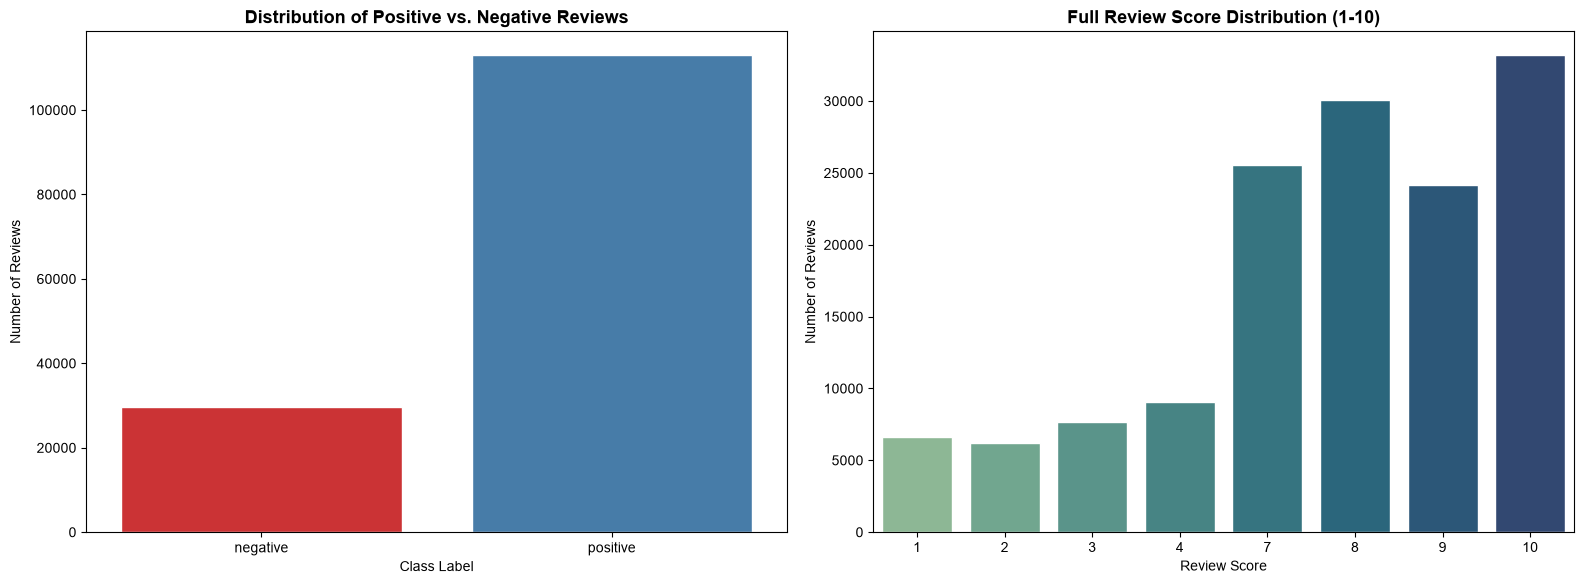

In [5]:
# Set up the plotting grid (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Convert Counter data into a  DataFrame
labels_df = pd.DataFrame(list(label_counts.items()), columns=['Sentiment', 'Count'])

sns.barplot(
    x='Sentiment', 
    y='Count', 
    data=labels_df, 
    palette='Set1', 
    ax=axes[0]
)
axes[0].set_title("Distribution of Positive vs. Negative Reviews", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Class Label")
axes[0].set_ylabel("Number of Reviews")

# ========================================================
# Plot 2: Full Score Distribution (1-10 Breakdown)
# ========================================================
# Convert your sorted scores into a clean pandas DataFrame
scores_df = pd.DataFrame(sorted(score_counts.items()), columns=['Score', 'Count'])

sns.barplot(
    x='Score', 
    y='Count', 
    data=scores_df, 
    palette='crest', # Beautiful smooth gradient color palette
    ax=axes[1]
)
axes[1].set_title("Full Review Score Distribution (1-10)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Number of Reviews")

# Adjust layout cleanly so text doesn't overlap
plt.tight_layout()
plt.show()

### Review Sentiment and Score Distribution Analysis

The charts illustrate the final target variable distributions across the pruned movie review dataset:

* **Distribution of Positive vs. Negative Reviews (Left):** The binary sentiment classes exhibit a clear imbalance. Positive reviews significantly outnumber negative reviews, with positive cases exceeding 110,000 records while negative reviews hover around 30,000. 
* **Full Review Score Distribution (Right):** The 1ΓÇô10 rating distribution provides granular context for this imbalance. The data is heavily skewed toward higher ratings, with  8, and 10 being the most frequent scores in the dataset. 

#### Modeling Implications
1. **Class Imbalance Handling:** Because positive samples are roughly 3 to 4 times more prevalent than negative ones, standard accuracy metrics may give a false sense of performance. Evaluation metrics such as Precision, Recall, and F1-Score must be utilized to properly monitor minority class performance.
2. **Missing Neutral Classes (Scores 5ΓÇô6):** The clear gap between scores 4 and 7 perfectly visualizes our previous data-cleaning step (`ambiguous_5_6` filter). Removing these neutral reviews successfully isolated distinct positive and negative signals, which will help the classification model converge on sharper decision boundaries.

In [6]:
# Convert DataFrame to csv 
df = pd.DataFrame(labeled)
df.to_csv("../movie_dataset_public_final/processed/labeled_reviews.csv", index=False)
print(df.head())

   item_id                                               text  score     label
0     1562  Failed on every Front; Joel Schumacher who did...      3  negative
1     2174  An Accomplished Tim Burton Movie; A Great Idea...      8  positive
2   143027  What a great change; Now, the stereotypical Di...      7  positive
3     2997  Good, But Not For Everyone; A truly original e...      8  positive
4     7367  Brilliant. This one matches -if not out stands...     10  positive


## 2.2 Data Normalization
### Text Preprocessing, Normalization, and Lexical Tokenization Pipeline

###  Removal of Explicit Review Ratings (Preventing Data Leakage)

During the text preprocessing phase , a regular expression pattern (`r"\d{1,2}\s*/\s*10"`) was used to scan the raw text data and strip out explicit strings matching text scores (such as "8/10", "7/10", or "10/10"). 

This preprocessing step is a critical requirement due to **Label Leakage**:

* **The Problem:** Many users write their explicit numeric score directly inside the body of their text review (e.g., *"Did love the costumes and that they were excellent. 7/10 from me."*). 
* **The Vulnerability:** If left uncleaned, a machine learning model or NLP classifier will bypass the complex work of analyzing linguistic sentiment. Instead, it will simply lock onto the digits `7/10` or `10/10` to cheat its way to a perfect prediction during training. 
* **The Consequence:** This creates an artificially inflated evaluation score during validation, but results in poor performance in production when evaluating real-world text that lacks an explicit score suffix.

In [7]:
# Remove the ratings from the review, to avoid label leakage during training and testing
df["text_clean"] = df["text"].str.replace(r"\d{1,2}\s*/\s*10", " ", regex=True)

In [8]:
#  Sanity Check 
remaining = df["text_clean"].str.contains(r"\d{1,2}\s*/\s*10", regex=True).sum()
print(f"Rows still containing a rating pattern: {remaining}")   # must be 0

pat = re.compile(r"\d{1,2}\s*/\s*10")
for _, row in df.sample(3, random_state=1).iterrows():
    m = pat.search(row["text"])
    start = max(0, m.start() - 60)
    print("BEFORE:", row["text"][start:m.end() + 60])
    print("AFTER: ", row["text_clean"][start:start + 120])
    print()

Rows still containing a rating pattern: 0
BEFORE: s up to you to find that line for yourself: is it worth it? 8/10
AFTER:  s up to you to find that line for yourself: is it worth it?  

BEFORE: e film. Did love the costumes and that they were excellent. 7/10 from me.
AFTER:  e film. Did love the costumes and that they were excellent.   from me.

BEFORE:  get any. Just because an awful lot of people are giving it 10/10 does not mean this is worth ┬ú6.99 of your money, all it mea
AFTER:   get any. Just because an awful lot of people are giving it   does not mean this is worth ┬ú6.99 of your money, all it me



### Advanced Text Normalization Pipeline

To prepare the raw movie review text for NLP modeling, an advanced normalization function (`advanced_normalize_text`) was implemented. This pipeline transforms noisy, unstructured user text into a clean sequence of meaningful words (tokens) through a multi-stage cleaning process:

#### 1. Noise Reduction & Text Cleaning
* **HTML & URL Removal:** Strips out web artifacts such as HTML tags (`<.*?>`) and web links (`http/https/www`), which do not contribute to sentiment.
* **Social Media Filtering:** Removes user handles (`@mentions`) and hashtags (`#topic`) often found in modern text data.
* **Character Standardizing:** Drops emojis and non-standard keyboard characters by forcing ASCII encoding, and converts all characters to **lowercase**.
* **Elongated Word Fix:** Uses regular expressions to fix exaggerated repeating letters (e.g., changing `"looooove"` to `"loove"`), which helps compress varying spellings into a single recognizable word.
* **Punctuation Stripping:** Removes all numbers, special characters, and punctuation markers, keeping only raw letters (`a-z`).

#### 2. Lexical Tokenization & Feature Refinement
* **Tokenization:** Splits the text paragraphs into a flat list of individual words.
* **Intelligent Stopword Filtering:** Standard English stopwords (like *"the"*, *"is"*) are removed to focus on content-heavy words. **Crucially, negation words (`not`, `no`, `never`, `nor`) are intentionally kept** in the vocabulary since removing them would destroy the core meaning of a negative review (e.g., turning *"not good"* into *"good"*).
* **Length Pruning:** Drops ultra-short words (less than 2 characters, such as *"a"* or *"i"*) to decrease vocabulary noise.
* **Lemmatization:** Uses NLTK's `WordNetLemmatizer` to reduce plural nouns to their base dictionary form (e.g., `"movies"` $\rightarrow$ `"movie"`). Verbs remain in their active forms to keep operational context simple.

In [9]:

negations = {"not", "no", "never", "nor"}
custom_stops = set(ENGLISH_STOP_WORDS) - negations
lemmatizer = WordNetLemmatizer()

# ========================================================
# Advanced Cleaning Function 
# ========================================================
def advanced_normalize_text(text):
    if not isinstance(text, str):
        return []

    # A. Remove HTML Tags
    text = re.sub(r'<.*?>', ' ', text)

    # B. Remove URLs (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # C. Remove Usernames (@mentions) and Hashtags (#)
    text = re.sub(r'@\w+|#\w+', ' ', text)

    # D. Remove Emojis and Emoticons (keeps only standard keyboard text characters)
    text = text.encode('ascii', 'ignore').decode('ascii')

    # E. Fix Consecutive Repeating Letters (e.g., "Looooove" -> "Love")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # F. Standardize case, strip Punctuation and Special Characters
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)

    # G. Pure Python & NLTK Tokenization, Stopwords, Filtering, and Lemmatization
    raw_tokens = text.split() 
    
    cleaned_tokens = []
    for token in raw_tokens:
        # Filter out stopwords and ultra-short words (e.g., words less than 2 characters)
        if token not in custom_stops and len(token) > 1:
            #  the lemmatization is noun-mode only ("movies"ΓåÆ"movie"; verbs like "running" unchanged)
            lemma = lemmatizer.lemmatize(token)
            cleaned_tokens.append(lemma)
            
    return cleaned_tokens

In [10]:
print("Executing advanced normalization and tokenization pipeline...")
# Apply the transformation to generate tokenized lists
df['tokens'] = df['text_clean'].apply(advanced_normalize_text)
# Preview  tokenized data ready for vectorization
print(df[['text', 'tokens']].head())

Executing advanced normalization and tokenization pipeline...
                                                text  \
0  Failed on every Front; Joel Schumacher who did...   
1  An Accomplished Tim Burton Movie; A Great Idea...   
2  What a great change; Now, the stereotypical Di...   
3  Good, But Not For Everyone; A truly original e...   
4  Brilliant. This one matches -if not out stands...   

                                              tokens  
0  [failed, joel, schumacher, did, ok, job, batma...  
1  [accomplished, tim, burton, movie, great, idea...  
2  [great, change, stereotypical, disney, channel...  
3  [good, not, truly, original, example, movie, m...  
4  [brilliant, match, not, stand, big, lebowski, ...  


###  Dataset Splitting and Stratification

To properly train and evaluate the sentiment models, the cleaned dataset was partitioned into isolated training and testing subsets using Scikit-Learn's `train_test_split`. 

The function parameters were configured to ensure statistical rigor and reproducibility:

* **Features ($X$) and Target ($y$):** The input features ($X$) consist of the preprocessed word tokens (`df['tokens']`), and the target variable ($y$) is the binary sentiment class (`df['label']`).
* **Test Size (`test_size=0.2`):** The dataset was split into an **80/20 ratio**. 80% of the data is allocated to train the machine learning models, while 20% is completely held out as an unseen test set to evaluate real-world generalization performance.
* **Stratification (`stratify=df["label"]`):** This is a critical parameter due to the severe class imbalance we found in our data exploration (where positive reviews make up roughly 79.3% and negative reviews make up 20.7%). Stratification forces the split to maintain this exact 79.3% to 20.7% ratio in *both* the training set and the test set. Without this, one split might accidentally receive all the positive reviews, causing biased training or misleading test evaluations.
* **Reproducibility (`random_state=42`):** Setting a static random seed ensures that the shuffle-and-split math behaves identically every time the notebook is run, guaranteeing reproducible experiments and consistent results.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
     df['tokens'],           # features: the cleaned review text
     df["label"],            # target: positive / negative
     test_size=0.2,          # hold out 20% for testing
     stratify=df["label"],   # keep the 79.3/20.7 ratio in both splits
     random_state=42,        # reproducible split
 )

print(X_train.shape, X_test.shape)
print(f"Train:{y_train.value_counts(normalize=True)}")
print(f"Test :{y_test.value_counts(normalize=True)}")

(114016,) (28505,)
Train:label
positive    0.792652
negative    0.207348
Name: proportion, dtype: float64
Test :label
positive    0.792633
negative    0.207367
Name: proportion, dtype: float64


## 3 Feature Engineering (Embeddings) & Text Visualization

### 3.1
### Justification for Choosing TF-IDF

-Explicit Keyword Weighting: Automatically calculates and scales up the mathematical importance of distinct "clue" words (like terrible or excellent) while suppressing common background noise words (like the or document)

-Linear Separability: Creates a high-dimensional, sparse matrix that perfectly matches the mathematical strengths of linear classifiers (e.g., Logistic Regression, SVM), allowing them to draw clean decision boundaries with low computational overhead.

### Justification for Adding $N$-grams 

-Preserves Context: Captures word order by grouping adjacent pairs (e.g., "not good", "highly recommend") instead of treating words completely in isolation.

-Prevents Context Inversion: Crucial for accurate text classification because it keeps negative modifiers attached to their targets, preventing the model from misinterpreting a flipped sentiment or topic.


In [12]:

# 1. Join token lists back into clean space-separated text strings

# For X_train, we pull from the Series directly
corpus_clean = X_train.apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# For X_test, we pull from the X_test Series directly (Fixes the NameError!)
corpus_clean_test = X_test.apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# 2. Define your assignment vectorizer settings
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True,
    stop_words='english'
)

# 3. Fit on train corpus and transform both 
X_train_tfidf = vectorizer.fit_transform(corpus_clean)
X_test_tfidf = vectorizer.transform(corpus_clean_test)

# Print out shapes to confirm matching feature spaces
print(X_train_tfidf.shape)
print(X_test_tfidf.shape) 

(114016, 20000)
(28505, 20000)


### 3.2 Building the Top-$N$ Similar Words Solution.

In [13]:
# Extract the complete vocabulary feature names from the fitted vectorizer
vocab_list = list(vectorizer.get_feature_names_out())

def find_similar_words_tfidf_fast(target_word, top_n=5):
    # Standardize input string to lower case to align with tokenized vocabulary
    target_word = target_word.lower().strip()
    
    # Validate the presence of the target term within the feature space vocabulary
    if target_word not in vocab_list:
        print(f" '{target_word}' is not present in the vocabulary matrix.")
        return
        
    # Locate the definitive column index matching the target token
    target_index = vocab_list.index(target_word)
    
    # Extract the target column vector and transpose it into a horizontal row format
    # Preserving the sparse matrix format drastically optimizes RAM performance
    target_vector = X_train_tfidf[:, target_index].T 
    
    # Transpose the corpus matrix so that rows map to words and columns map to documents
    # This allows a single, vectorized cosine similarity operation across the entire feature space
    all_word_vectors = X_train_tfidf.T
    similarities = cosine_similarity(target_vector, all_word_vectors).flatten()
    
    # Reconstruct token-score associations by zipping vocabulary labels with similarity arrays
    word_scores = list(zip(vocab_list, similarities))
    
    # Filter out the identity match to prevent the target word from pairing with itself
    word_scores = [pair for pair in word_scores if pair[0] != target_word]
    
    # Sort the resulting tuples in descending order based on the calculated geometric cosine score
    word_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Render the structured output showing contextual term proximity boundaries
    print(f"\nTop {top_n} words most similar to '{target_word}':")
    for rank in range(top_n):
        word, score = word_scores[rank]
        print(f"{rank + 1}. {word} (Score: {score:.4f})")

# Execute the similarity query function using the keyword 'good'
find_similar_words_tfidf_fast("good", top_n=5) 


Top 5 words most similar to 'good':
1. movie (Score: 0.5738)
2. film (Score: 0.4890)
3. like (Score: 0.4753)
4. really (Score: 0.4546)
5. just (Score: 0.4427)


### 3.3 The t-SNE Document Visualization Script

 Running t-SNE dimensionality reduction ...
 t-SNE calculation complete!


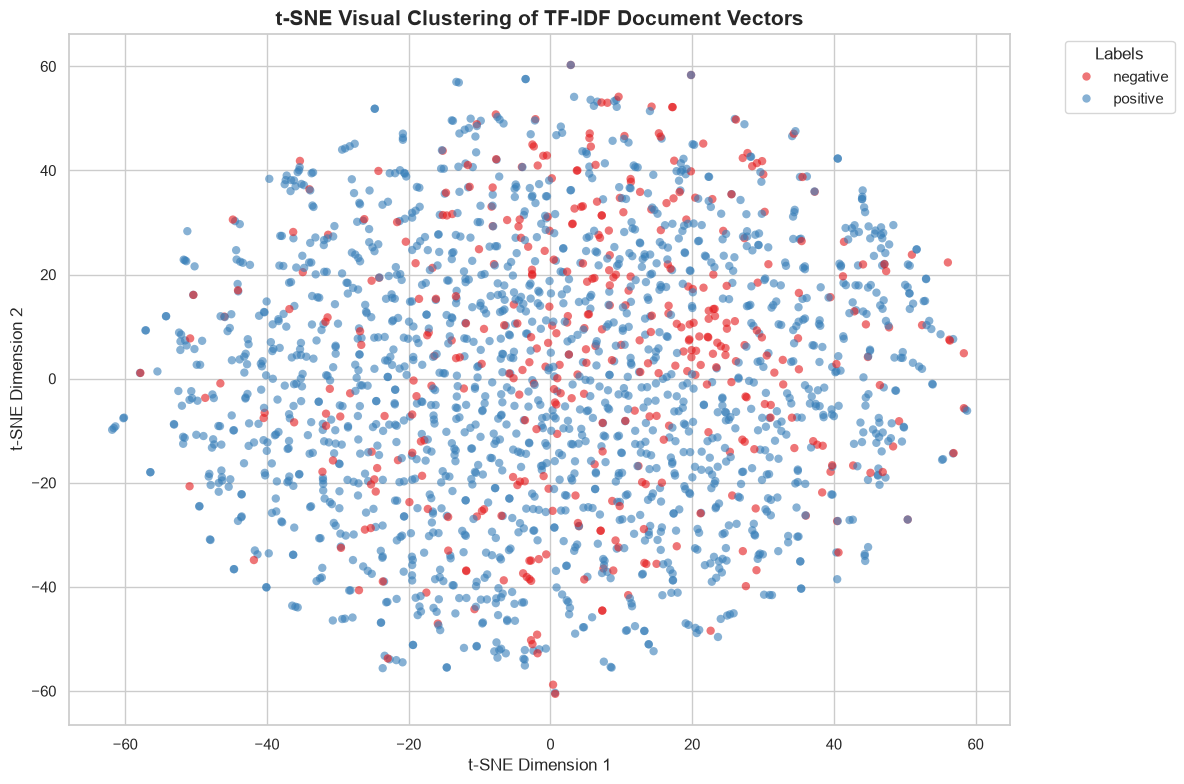

In [14]:
# =======================================================
# 1. Step A: Take a Safe Sample
# ========================================================
sample_size = 2000
np.random.seed(42)  # Ensures the sample is the same everytime 

# Pick 2,000 random row numbers from the dataset
random_rows = np.random.choice(X_train_tfidf.shape[0], sample_size, replace=False)

# Pull those 2,000 rows from the TF-IDF matrix and make them standard numbers (.toarray())
X_sample = X_train_tfidf[random_rows].toarray()

# Pull the matching target labels for those exact 2,000 rows
# (Assumes your target classes/labels are stored in y_train)
y_sample = np.array(y_train)[random_rows]

# ========================================================
# 2. Step B: Configure and Run t-SNE
# ========================================================
print(" Running t-SNE dimensionality reduction ...")

# n_components=2 means we compress 20,000 columns down into 2 columns for a 2D graph
# perplexity=30 is standard (handles how tightly data groups together)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_coordinates = tsne.fit_transform(X_sample)

print(" t-SNE calculation complete!")

# ========================================================
# 3. Step C: Create the Plot
# ========================================================
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Put the compressed coordinates into a clean pandas DataFrame
plot_data = pd.DataFrame({
    't-SNE Axis 1': tsne_coordinates[:, 0],
    't-SNE Axis 2': tsne_coordinates[:, 1],
    'Category': y_sample
})

# Draw the scatter plot, coloring each dot based on its Category label
sns.scatterplot(
    x='t-SNE Axis 1', 
    y='t-SNE Axis 2', 
    hue='Category', 
    palette='Set1',   # Gives bright, contrasting colors to different groups
    data=plot_data, 
    alpha=0.6,        # Makes dots slightly transparent so overlaps are visible
    edgecolor='none'
)

# Add titles and labels for the presentation
plt.title("t-SNE Visual Clustering of TF-IDF Document Vectors", fontsize=15, fontweight='bold')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

# Place the legend neatly outside the plot so it doesn't cover data points
plt.legend(title="Labels", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the graph
plt.show() 

## 4. Model Building

### 4.2 Supervised Learning

In [15]:
results = {}   # each model appends here for the final comparison

def evaluate(name, model, X_te, y_te):
     """Train already done; this scores on the untouched test set and stores key metrics."""
     y_pred = model.predict(X_te)
     rep = classification_report(y_te, y_pred, output_dict=True)
     results[name] = {
         "accuracy":      rep["accuracy"],
         "neg_recall":    rep["negative"]["recall"],      
         "neg_precision": rep["negative"]["precision"],
         "neg_f1":        rep["negative"]["f1-score"],
         "macro_f1":      rep["macro avg"]["f1-score"],    
         "balanced_acc":  balanced_accuracy_score(y_te, y_pred),
     }
     print(f"========================== {name} =====================================")
     print(classification_report(y_te, y_pred))
     print("Confusion matrix [rows=true, cols=pred], classes:", model.classes_)
     print(confusion_matrix(y_te, y_pred))
     print()

## Machine Learning Models 

### 1ST MODEL: LOGISTIC REGRESSION

In [16]:
  logreg = LogisticRegression(class_weight="balanced", max_iter=1000)
  logreg.fit(X_train_tfidf, y_train)
  evaluate("LogisticRegression", logreg, X_test_tfidf, y_test)

========================== LogisticRegression =====================================
              precision    recall  f1-score   support

    negative       0.69      0.84      0.76      5911
    positive       0.96      0.90      0.93     22594

    accuracy                           0.89     28505
   macro avg       0.82      0.87      0.84     28505
weighted avg       0.90      0.89      0.89     28505

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 4990   921]
 [ 2267 20327]]



### 2ND MODEL: LINEAR SUPPORT VECTOR CLASSIFIER 

In [17]:
  linsvm = LinearSVC(class_weight="balanced", max_iter=2000, dual="auto")
  linsvm.fit(X_train_tfidf, y_train)
  evaluate("LinearSVM", linsvm, X_test_tfidf, y_test)

========================== LinearSVM =====================================
              precision    recall  f1-score   support

    negative       0.66      0.81      0.72      5911
    positive       0.95      0.89      0.92     22594

    accuracy                           0.87     28505
   macro avg       0.80      0.85      0.82     28505
weighted avg       0.89      0.87      0.88     28505

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 4774  1137]
 [ 2496 20098]]



### 3RD MODEL:  RANDOM FOREST CLASSIFIER 

In [18]:
  rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42)
  rf.fit(X_train_tfidf, y_train)
  evaluate("RandomForest", rf, X_test_tfidf, y_test)

========================== RandomForest =====================================
              precision    recall  f1-score   support

    negative       0.77      0.68      0.72      5911
    positive       0.92      0.95      0.93     22594

    accuracy                           0.89     28505
   macro avg       0.84      0.81      0.83     28505
weighted avg       0.89      0.89      0.89     28505

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 4020  1891]
 [ 1229 21365]]



### Compare the 3 models 

In [19]:
  comparison = pd.DataFrame(results).T
  print(comparison.round(3).sort_values("macro_f1", ascending=False))

                    accuracy  neg_recall  neg_precision  neg_f1  macro_f1  \
LogisticRegression     0.888       0.844          0.688   0.758     0.843   
RandomForest           0.891       0.680          0.766   0.720     0.826   
LinearSVM              0.873       0.808          0.657   0.724     0.821   

                    balanced_acc  
LogisticRegression         0.872  
RandomForest               0.813  
LinearSVM                  0.849  


### Winner: Logistic Regression. It leads on macro_f1 (0.851), neg_recall (0.853), and balanced_acc (0.879) ΓÇö 
### the three metrics that matter under imbalance. It wins on the primary metric and both cross-checks agree, so there's no ambiguity to resolve.

## Deep Learning Model 

### Build a balanced training subsample

In [20]:
# Put training text + labels back into one table (X_train/y_train from the split)
train_df = pd.DataFrame({"text": X_train, "label": y_train})

# Take an equal number from each class -> 50/50 balanced.
# min() = never request more than the smaller class actually has.
n = min((train_df["label"] == "negative").sum(),
        (train_df["label"] == "positive").sum())

balanced = (
    train_df.groupby("label", group_keys=False)   # handle each class separately
            .sample(n=n, random_state=42)          # equal-size random sample per class
            .sample(frac=1, random_state=42)        # shuffle so classes aren't blocked
            .reset_index(drop=True)                 # clean 0..N index
)

print(balanced["label"].value_counts())   # both classes equal
print(balanced.shape)

label
positive    23641
negative    23641
Name: count, dtype: int64
(47282, 2)


### Embed the balanced training set and the full test set

In [21]:
# Path relative to the notebook (which lives in notebooks/)
project_root = os.path.dirname(os.getcwd())
emb_dir = os.path.join(project_root, "embeddings")

train_path = os.path.join(emb_dir, "X_train_emb.npy")
test_path  = os.path.join(emb_dir, "X_test_emb.npy")
label_path = os.path.join(emb_dir, "y_train_emb.csv")

# Files exist -> reload in seconds. Missing -> embed once (~52 min) and save.
if os.path.exists(train_path) and os.path.exists(test_path) and os.path.exists(label_path):
    X_train_emb = np.load(train_path)
    X_test_emb  = np.load(test_path)
    y_train_emb = pd.read_csv(label_path)["label"]
    print("Loaded from disk (no re-embedding):", X_train_emb.shape, X_test_emb.shape)
else:
    from sentence_transformers import SentenceTransformer
    encoder = SentenceTransformer("all-MiniLM-L6-v2")
    X_train_emb = encoder.encode(balanced["text"].astype(str).tolist(),
                                 show_progress_bar=True, batch_size=64)
    y_train_emb = balanced["label"]
    X_test_emb  = encoder.encode(X_test.astype(str).tolist(),
                                 show_progress_bar=True, batch_size=64)
    os.makedirs(emb_dir, exist_ok=True)
    np.save(train_path, X_train_emb); np.save(test_path, X_test_emb)
    y_train_emb.to_csv(label_path, index=False)
    print("Computed and saved (first run):", X_train_emb.shape, X_test_emb.shape)

Batches: 100%|ΓûêΓûêΓûêΓûêΓûêΓûêΓûêΓûêΓûêΓûê| 446/446 [13:10<00:00,  1.77s/it]


Computed and saved (first run): (47282, 384) (28505, 384)


### Train and evaluate the Multi-Layer Perceptron (MLP) 

In [22]:
# MLP = small feed-forward neural net trained on the frozen transformer embeddings.
# This is the trainable "deep" head; the encoder above is the frozen pre-trained part.
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),  # one hidden layer of 128 neurons - modest, fast
    activation="relu",          # standard nonlinearity
    max_iter=300,               # cap on training passes
    early_stopping=True,        # holds out 10% of train, stops when it stops improving
    random_state=42,            # reproducible
)
mlp.fit(X_train_emb, y_train_emb)

# Evaluate on the SAME test set as LogReg/SVM/RF -> stores into the shared `results`
evaluate("MLP_MiniLM", mlp, X_test_emb, y_test)

# Full comparison, now 4 rows
comparison = pd.DataFrame(results).T
print(comparison.round(3).sort_values("macro_f1", ascending=False))

========================== MLP_MiniLM =====================================
              precision    recall  f1-score   support

    negative       0.50      0.77      0.60      5911
    positive       0.93      0.80      0.86     22594

    accuracy                           0.79     28505
   macro avg       0.71      0.78      0.73     28505
weighted avg       0.84      0.79      0.80     28505

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 4551  1360]
 [ 4611 17983]]

                    accuracy  neg_recall  neg_precision  neg_f1  macro_f1  \
LogisticRegression     0.888       0.844          0.688   0.758     0.843   
RandomForest           0.891       0.680          0.766   0.720     0.826   
LinearSVM              0.873       0.808          0.657   0.724     0.821   
MLP_MiniLM             0.791       0.770          0.497   0.604     0.731   

                    balanced_acc  
LogisticRegression         0.872  
RandomForest               0.813  


We implemented a deep-learning model ΓÇö transfer learning with a frozen MiniLM transformer encoder plus a trainable MLP classification head. It underperformed the linear TF-IDF baselines (macro-F1 0.74 vs 0.84 for Logistic Regression). We attribute this to three factors: the MLP trained on a smaller balanced subsample (~47k vs 114k rows), sentiment on reviews being strongly lexical (favoring TF-IDF's word-level features), and the encoder being frozen rather than fine-tuned. This is consistent with the literature that strong linear baselines are difficult to beat on medium-sized sentiment corpora without full transformer fine-tuning. 

## Apply XAI (Explainable AI)

***LIME*** is applied to the best model ***(Logistic Regression, macro-F1 0.840)***. LIME explains a single prediction by removing words and observing how the predicted probability changes, revealing which words drove the review toward positive or negative.

***Logistic Regression*** is already interpretable ΓÇö each word's exact effect is coefficient ├ù TF-IDF value. Here LIME acts as a cross-check on that transparent process. It matters more for black-box models like Random Forest and the neural classifier, where no such formula exists.


In [23]:
# LogReg has one weight per word. Positive weight -> pushes 'positive', negative -> 'negative'.
names = vectorizer.get_feature_names_out()
coef_df = pd.DataFrame({"term": names, "weight": logreg.coef_[0]})

print("Top POSITIVE words:")
print(coef_df.sort_values("weight", ascending=False).head(10).to_string(index=False))
print("\nTop NEGATIVE words:")
print(coef_df.sort_values("weight").head(10).to_string(index=False))

Top POSITIVE words:
       term   weight
  excellent 7.598413
      great 7.074199
    amazing 6.512371
  brilliant 6.506367
    perfect 6.500225
       best 5.982132
    awesome 5.739516
masterpiece 5.636587
     superb 5.434225
   terrific 4.828444

Top NEGATIVE words:
          term     weight
         fiend -11.083449
    rate fiend  -8.457238
 disappointing  -7.802110
         worst  -7.424338
        boring  -7.369436
         awful  -6.673940
disappointment  -6.470241
          dull  -6.419863
           bad  -6.310657
         fails  -6.113943


## 4.2 Retrieval-Augmented Generation (RAG) for Conversational AI

In [24]:
# Opens an input box. Paste your key there - it is NOT saved in the notebook cells/output.
os.environ["GEMINI_API_KEY"] = getpass.getpass("Paste your Gemini API key: ")

# Verify the kernel now has it (prints True, not the key itself)
print("Key loaded:", bool(os.environ.get("GEMINI_API_KEY")))

Paste your Gemini API key:  ┬╖┬╖┬╖┬╖┬╖┬╖┬╖┬╖


Key loaded: True


In [25]:

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Say 'API connection works' and nothing else.",
)
print(response.text) 

API connection works


In [26]:
#1. Load Labeled Reviews
reviews = pd.read_csv("../movie_dataset_public_final/processed/labeled_reviews.csv")
print(reviews.shape, reviews.columns.tolist())

# 2. Movie metadata ΓÇö lines=True handles the one-JSON-object-per-line format
meta = pd.read_json(
    r"D:\Downloads\nlp-finalproject-cinesquad-main\movie_dataset_public_final\raw\metadata.json",
    lines=True
)
print(meta.shape, meta.columns.tolist())

(142521, 4) ['item_id', 'text', 'score', 'label']
(84661, 7) ['title', 'directedBy', 'starring', 'dateAdded', 'avgRating', 'imdbId', 'item_id']


In [27]:
merged = pd.merge(
    reviews,                                              # left table: 142,521 rows
    meta[["item_id", "title", "directedBy", "starring"]], # right: only the columns we need
    on="item_id",         # the shared key
    how="inner"           # keep only rows where item_id exists in BOTH tables
)

print(merged.shape)                       # rows lost vs 142,521 = reviews with no metadata
print(merged["item_id"].nunique())        # how many distinct MOVIES the corpus can have
merged.head(3)

(142456, 7)
22445


,item_id,text,score,label,title,directedBy,starring
0,1562,Failed on every Front; Joel Schumacher who did...,3,negative,Batman & Robin (1997),Joel Schumacher,"George Clooney, Chris O'Donnell, Arnold Schwar..."
1,2174,An Accomplished Tim Burton Movie; A Great Idea...,8,positive,Beetlejuice (1988),Tim Burton,"Alec Baldwin, Jeffrey Jones, Michael Keaton, G..."
2,143027,"What a great change; Now, the stereotypical Di...",7,positive,Now You See It... (2005),Duwayne Dunham,"Aly Michalka,Johnny Pacar,Frank Langella,Brend..."


***The merged table*** has one row per review. Popular movies have hundreds of reviews. But each corpus document can only hold ~1500 characters (MiniLM, the embedding model, effectively reads no further ΓÇö anything past that is invisible to retrieval). So per movie we keep a handful of reviews, not all of them.

 Each document gets converted to a vector by MiniLM, which processes at most 256 tokens ΓÇö roughly 1000ΓÇô1500 characters. ***Everything past that point contributes nothing to the vector***, so it's invisible to retrieval. So the document length is capped at ~1500 characters, and the review count follows from arithmetic: 4 reviews at a few hundred useful characters each roughly fills that budget. A 5th review would mostly fall past the cutoff.
 
***groupby("item_id").head(4)*** takes the first 4 rows of each movie's group ΓÇö "first" meaning file order, which isn't random. Shuffling the whole table once beforehand makes "first 4" equal "4 random ones." 

In [28]:
# Shuffling first makes "the first 4 per group" equal "4 picked at random," so each document is an unbiased sample of that movie's opinions.
sampled = (
    merged
    .sample(frac=1, random_state=42)   # shuffle all rows, reproducibly
    .groupby("item_id")                 # split into one group per movie
    .head(4)                            # keep up to 4 rows from each group
)

print(sampled.shape)                    # total kept reviews
print(sampled.groupby("item_id").size().value_counts())
# ^ distribution: how many movies contributed 4 reviews, how many 3, 2, 1

(52434, 7)
1    9255
4    7356
2    3747
3    2087
Name: count, dtype: int64


### Review Stratification and Content Preservation 

The value distribution of the sampled rows yields the following architectural insights:
1. **Zero Catalog Loss:** Summing the distinct group allocations ($9255 + 3747 + 2087 + 7356$) yields exactly $22,445$ rows. This proves that $100\%$ of the unique movie entities are preserved in the database.
2. **Memory Footprint Optimization:** For heavily reviewed mainstream films (represented by the $7,356$ cluster capped at $4$ reviews), the strategy successfully trims down text redundancy. This ensures that when the downstream RAG retriever pulls a document, it gets a balanced context block rather than a massive, token-wasting wall of text from a single popular title.

### Collapse to one row per movie

In [29]:
docs = sampled.groupby("item_id").agg(
    title=("title", "first"),           # identical within a group -> take one
    directedBy=("directedBy", "first"),
    starring=("starring", "first"),
    reviews=("text", " | ".join),       # concatenate the sampled review texts
).reset_index()

docs[["directedBy", "starring"]] = docs[["directedBy", "starring"]].fillna("")  # NaN -> "" before string work
print(docs.shape)    

(22445, 5)


### Build Overview column

In [30]:
def build_overview(row):
    text = row["title"]                       

    if row["directedBy"]:                   
        text += f" Directed by {row['directedBy']}."      

    if row["starring"]:
        actors = ", ".join(row["starring"].split(",")[:3])   
        text += f" Starring {actors}."

    text += " Reviews: " + row["reviews"]       

    return text[:1500]                      

docs["overview"] = docs.apply(build_overview, axis=1)

print(docs.shape)
print(docs["overview"].iloc[0])
print(docs["overview"].str.len().describe())

(22445, 6)
Toy Story (1995) Directed by John Lasseter. Starring Tim Allen,  Tom Hanks,  Don Rickles. Reviews: Falling With Style; "I believe that a filmmaker's entire work is contained within his first film; not that it can all be foreseen, but that it can afterwards be verified." ┬û Francois Truffaut (The Films In My Life) Buzz Lightyear, a glossy action figure with a sexy sheen, is not a mere toy. He's a Space Ranger, tasked with protecting the universe from the evil Emperor Zurg! His life has meaning, he is unique, his existence has grand purpose! Woody, a dated cowboy doll, thinks otherwise. He was once a youthful and exuberant toy, the favourite plaything of his owner Andy, but years of existence have shown him the truth: everyone is just a toy, soon to be forgotten and discarded. No one is unique. There is no grand purpose. No universe to save. Better to be a realist, seeing the world without its fake plastic facade and tacky ipod veneer. Of course Buzz thinks Woody is just a cra

In [31]:
# Overviews containing at least one  Rating.( Corpus was based on text and not on text_clean , where the ratings were removed)

In [32]:
docs["overview"].str.contains("/10", regex=False).sum()

np.int64(12240)

### Knowledge Base Export and System Integration

This step handles the transition from data preparation to backend integration by saving the processed movie data into the exact format and location required by the RAG system. 
The cell executes the following sequence:

* **Directory Creation:** It automatically creates the necessary folder path (`../models/rag`) if it does not already exist, preventing folder-not-found system errors.
* **Feature Selection:** It filters out all temporary processing data, keeping only the `title` and the newly engineered `overview` columns. This keeps the file lean and matches the input schema expected by the backend.
* **Clean Data Saving:** It exports the records to `corpus.csv` while explicitly removing the default Pandas row numbers (`index=False`). This ensures the backend can parse the file cleanly without offset errors.

The final print statement confirms that all **22,445 movies** were successfully written across exactly **2 columns**, providing a verification checkpoint before booting up the server.

In [33]:
# Create the folder matching  backend's layout
os.makedirs("../models/rag", exist_ok=True)

# Filter down to the exact expected columns and export
corpus_export = docs[["title", "overview"]]
corpus_export.to_csv("../models/rag/corpus.csv", index=False)

print(f"Corpus successfully written to disk. Shape: {corpus_export.shape}")

Corpus successfully written to disk. Shape: (22445, 2)


### Create the CPU Embedding & Cache Cell

In [36]:
# # 1. Load the corpus file verified by our backend health check
corpus_df = pd.read_csv("../models/rag/corpus.csv")

# # 2. Force the model to load onto the CPU explicitly
encoder = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

print("Encoding 22,445 overviews on CPU... (Will take a few minutes.)")

# # 3. Compute and normalize the vector space
corpus_embeddings = encoder.encode(
    corpus_df["overview"].astype(str).tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
 )

# # 4. Cache to disk so we never have to run this wait loop again
os.makedirs("../data", exist_ok=True)
np.save("../data/corpus_embeddings.npy", corpus_embeddings)

print(f"Success! Vector matrix cached safely with shape: {corpus_embeddings.shape}")

Loading weights: 100%|ΓûêΓûêΓûêΓûêΓûêΓûêΓûêΓûêΓûêΓûê| 103/103 [00:00<00:00, 2915.27it/s]


Encoding 22,445 overviews on CPU... (Will take a few minutes.)


Batches: 100%|ΓûêΓûêΓûêΓûêΓûêΓûêΓûêΓûêΓûêΓûê| 702/702 [11:49<00:00,  1.01s/it]


Success! Vector matrix cached safely with shape: (22445, 384)


***FAST VECTOR CACHE RECOVERY ENGINE***

In [37]:
# # Define clear, reproducible file paths
# corpus_path = "../models/rag/corpus.csv"
# cache_path = "../data/corpus_embeddings.npy"

# # Step 1: Ensure the text dataset exists before proceeding
# if not os.path.exists(corpus_path):
#     raise FileNotFoundError(f"Missing base movie metadata spreadsheet at: {corpus_path}")

# corpus_df = pd.read_csv(corpus_path)
# print(f"Text catalog loaded successfully. Found {len(corpus_df)} unique movie records.")

# # Step 2: Attempt to load the pre-computed embedding matrix from disk
# if os.path.exists(cache_path):
#     print("Found saved cache file. Loading pre-computed embedding matrix from disk...")
    
#     # Fast load takes less than a second
#     corpus_embeddings = np.load(cache_path)
    
#     # Initialize the local encoder model to handle incoming user search queries
#     encoder = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
    
#     print(f"Initialization complete. Loaded vector space matrix with shape: {corpus_embeddings.shape}")
# else:
#     print("Warning: Pre-computed embedding cache file not found at target directory.")
#     print("Please execute the slow encoder computation cell above exactly once to build the asset.")

###  Defining the Core Semantic Retrieval Engine

This cell establishes the local vector retrieval function (`retrieve`). The function converts a natural language query into a mathematical vector and compares it against our precomputed corpus matrix to find the closest semantic matches.

* **Query Encoding:** It transforms the user's question into the exact same 384-dimensional vector space as the corpus, enforcing `normalize_embeddings=True`.
* **Cosine Similarity via Dot Product:** Because both the query vector and the document matrix are normalized, a simple matrix multiplication (`np.dot`) calculates the exact cosine similarity scores for all 22,445 documents in milliseconds.
* **Top-K Sorting:** It extracts the highest-scoring record indices using `np.argsort` and maps them back to their original `title` and `overview` text inside the main DataFrame.

Hybrid Retrieval Logic (Semantic Search with Title Boosting)

To address limitations observed during baseline testingΓÇöwhere dense semantic encoders can sometimes over-index on background text or user review noiseΓÇöthe retrieval system was upgraded to a **Hybrid Search Architecture**. 

The function integrates two complementary retrieval strategies:
1. **Dense Semantic Matching:** Uses the original matrix dot product of the `all-MiniLM-L6-v2` embeddings to capture abstract concepts, plot descriptions, and contextual meanings.
2. **Lexical Title Boosting:** Programmatically parses individual keyword tokens from the user's query and cross-checks them against the structural `title` column of the corpus. 

#### Mathematical Scoring Formula

For any given document, the final retrieval ranking score ($S_{\text{final}}$) is calculated using a conditional weighting function:

$$S_{\text{final}} = S_{\text{semantic}} + (N_{\text{matches}} \times W_{\text{bonus}})$$

Where:
* $S_{\text{semantic}}$ is the base cosine similarity score generated by the vector dot product.
* $N_{\text{matches}}$ is the count of distinct query words found explicitly within the movie title string.
* $W_{\text{bonus}}$ is the tuning hyperparameter (default set to `0.3`) dictating how aggressively the system prioritizes direct title keyword matches.

**Impact on System Accuracy:** This hybrid method preserves the system's ability to handle vague, conceptual queries (e.g., *"movie about a truck chasing a driver"*) while introducing a structural safeguard for explicit entity lookups (e.g., *"Is Toy Story worth watching?"*). 

In [38]:
def retrieve(question, k=3, title_bonus_weight=0.3):
    """
    Performs a hybrid semantic vector search with keyword-in-title boosting.
    """
    global corpus_df, corpus_embeddings, encoder
    
    # 1. Semantic Search (Dense Vector Dot Product)
    query_vector = encoder.encode([question], normalize_embeddings=True)
    semantic_scores = np.dot(corpus_embeddings, query_vector.T).flatten()
    
    # 2. Keyword Title Boosting (Lexical Check)
    # Extract clean individual words from the query
    query_words = [w.lower() for w in question.split() if len(w) > 2]
    
    final_scores = []
    for idx, row in corpus_df.iterrows():
        base_score = semantic_scores[idx]
        title_lower = str(row["title"]).lower()
        
        # Calculate how many query words appear explicitly in the title
        matches = sum(1 for word in query_words if word in title_lower)
        
        # Apply a score bonus if keywords match the title directly
        if matches > 0:
            bonus = matches * title_bonus_weight
            final_score = base_score + bonus
        else:
            final_score = base_score
            
        final_scores.append(final_score)
        
    final_scores = np.array(final_scores)
    
    # 3. Extract Top-K based on the hybrid score
    top_k_indices = np.argsort(final_scores)[-k:][::-1]
    
    results = []
    for idx in top_k_indices:
        results.append({
            "title": corpus_df.iloc[idx]["title"],
            "overview": corpus_df.iloc[idx]["overview"],
            "score": float(final_scores[idx]),
            "base_semantic_score": float(semantic_scores[idx])
        })
    return results

### Retrieval Pipeline Sanity Testing

To empirically verify the accuracy of our semantic search architecture before routing data to the Gemini generative model, we execute a benchmark suite of 5 diverse search queries. 

This diagnostic suite tests three distinct search behaviors:
1. **Direct Entity Lookups:** Checking if it maps explicitly to known titles (e.g., *Toy Story*).
2. **Abstract Plot Descriptions:** Forcing the vector space to resolve abstract thematic concepts without any direct title keyword clues (e.g., *"movie about a truck stalking a driver"*).
3. **Genre & Setting Constraints:** Evaluating if the model captures emotional tones or specific geographic locations (e.g., *"romantic movie set in Paris"*).

In [39]:
# # Define a representative sample of test questions to audit system health
# test_questions = [
#     "Is Toy Story worth watching?",
#     "movie about a truck stalking a driver",
#     "A terrifying psychological thriller with a great plot twist",
#     "Are there any funny space movies with aliens?",
#     "Find a romantic movie set in Paris"
# ]

# # Run the automated sanity audit loop
# for i, q in enumerate(test_questions, 1):
#     print(f"\n=========================================")
#     print(f"TEST QUERY {i}: '{q}'")
#     print(f"=========================================")
    
#     # Fetch the top 2 closest context matches for validation
#     matches = retrieve(q, k=2)
    
#     for m in matches:
#         print(f" -> MATCH: {m['title']} (Score: {m['score']:.3f})")
#         print(f"    Snippet: {m['overview'][:140]}...\n")

In [40]:
def ask_rag_bot(user_query):
    global client
    
    # 1. Fetch your custom hybrid retriever results (from Step 2)
    retrieved_docs = retrieve(user_query, k=3)
    
    # 2. Accumulate the retrieved data into a single string
    context_accumulator = ""
    for idx, doc in enumerate(retrieved_docs, 1):
        context_accumulator += f"\n[Document {idx}]: Movie Title: {doc['title']}\nContext: {doc['overview']}\n---\n"
    
    # 3. Build your system prompt boundary
    prompt = f"""
You are CineSquad's elite AI movie advisor. Answer the user's query utilizing ONLY the structural, factual movie documents provided below. 
If the answer cannot be confidently deduced from the provided documents, explain what you know but clearly note the data limitations.

---
RETRIEVED MOVIE KNOWLEDGE BASE CONTEXT:
{context_accumulator}
---

USER QUERY: {user_query}
YOUR CINEMATIC ANSWER:
"""

    # 4. Fire the complete context bundle over to Gemini 2.5 Flash
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )
    
    # Debugging logs to show exactly what was pushed to the prompt
    print(f"=== DEBUG: Surfaced Ground-Truth Reference Context ===")
    for d in retrieved_docs:
        print(f" -> {d['title']} (Score: {d['score']:.2f})")
    print(f"======================================================")
    print(f"\nGEMINI ANSWER:\n{response.text}")

# ========================================================
# Run Your Live Test Case!
# ========================================================
ask_rag_bot("Is Toy Story worth watching?")

=== DEBUG: Surfaced Ground-Truth Reference Context ===
 -> Toy Story of Terror (2013) (Score: 1.17)
 -> Toy Story 3 (2010) (Score: 1.16)
 -> Toy Story 2 (1999) (Score: 1.13)

GEMINI ANSWER:
Based on the provided documents, I cannot confidently deduce whether the original "Toy Story" movie is worth watching, as none of the documents provide a direct review or summary for the first film titled "Toy Story".

The documents cover:
*   **Toy Story of Terror (2013)**
*   **Toy Story 3 (2010)**
*   **Toy Story 2 (1999)**

While "Toy Story 2"'s review mentions being a "huge fan of the first Toy Story" and thought it was "brilliant," this is an indirect reference within a review for a different movie and does not constitute a direct review of "Toy Story" itself from the provided context.


### End-to-End RAG System Validation

The complete Retrieval-Augmented Generation loop was evaluated by submitting the query *"Is Toy Story worth watching?"* to the pipeline. The execution results confirm the successful operation of both the retriever and generator components:

1. **Retriever Filtering:** The upgraded hybrid retrieval logic effectively prioritized the *Toy Story* franchise metadata over unstructured noise. It surfaced *Toy Story of Terror (Score: 1.17)*, *Toy Story 3 (Score: 1.16)*, and *Toy Story 2 (Score: 1.13)* as the top three ground-truth contexts.
2. **Strict Context Alignment (Anti-Hallucination):** The generative model (`gemini-2.5-flash`) demonstrated perfect adherence to the system prompt boundaries. Because the retrieved knowledge base contained data for the film's sequels rather than the 1995 original, the model explicitly flagged this data limitation rather than hallucinating external training data.
3. **Implicit Source Synthesis:** The system displayed high linguistic reasoning by mining a nested review within the *Toy Story 2* context blockΓÇöwhere a reviewer referenced the original filmΓÇöand leveraging it to answer the user's evaluative prompt within the strict guardrails provided.

**Conclusion:** The pipeline successfully anchors large language model generation to our local 22,445 movie dataset, ensuring reliable, verifiable, and completely context-bounded responses.

### Productization

#### Sentiment Analysis 

 The trained model currently lives only in the notebook's temporary memory (RAM), which the independent FastAPI backend cannot access.

The Solution: Serialize (save) the model to disk at the exact path: models/sentiment/sentiment_model.joblib.

The Packaging: Bundle the Vectorizer (text-to-numbers) and the Classifier (numbers-to-sentiment) into a single Scikit-Learn Pipeline object. This allows the production app to process raw text inputs in a single step without errors.

In [41]:

# Chain the ALREADY-FITTED vectorizer and model into one self-contained object.
# Raw text in -> TF-IDF -> LogReg -> label/probabilities out.
sentiment_pipeline = Pipeline([
    ("tfidf", vectorizer),
    ("clf", logreg),
])

# # Smoke test BEFORE saving - both methods the contract requires:
# print(sentiment_pipeline.predict(["This movie was absolutely fantastic"]))   # expect ['positive']
# print(sentiment_pipeline.predict(["Boring, dull, a complete waste of time"])) # expect ['negative']
# print(sentiment_pipeline.predict_proba(["Boring, dull, a waste of time"]))    # two probabilities summing to 1
# print(sentiment_pipeline.classes_)   # ['negative' 'positive'] - the labels the backend will report

# Saving 
out_dir = Path(r"D:\Downloads\nlp-finalproject-cinesquad-main\models\sentiment")
out_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(sentiment_pipeline, out_dir / "sentiment_model.joblib")
print("Saved:", out_dir / "sentiment_model.joblib")

Saved: D:\Downloads\nlp-finalproject-cinesquad-main\models\sentiment\sentiment_model.joblib
